# Post-Election Crypto Market Rally

## Research Context

The previous cases examine situations in which the modelled operational balance faces different types of stress.

This case looks at the opposite market environment: **a strong crypto-market rally**.

In the scenario modelled in this project, incoming volatile crypto payments are converted into **USDT** to reduce direct exposure to BTC and ETH price movements.

This creates a different question:

> **If BTC and ETH rise strongly after the conversion, does the USDT operational balance remain stable — and what does the company give up by no longer holding the volatile assets?**

Donald Trump won the 2024 U.S. presidential election on 5 November. During the following days, BTC and ETH rose substantially as the market operated under changing expectations about the future U.S. crypto-policy environment.

The election result is used as an external reference point for the analysis. The purpose is not to claim that every subsequent price movement was caused by the election.

The analysis uses two layers:

1. **BTC and ETH — broader market context**  
   These assets show the magnitude and timing of the post-election crypto-market rally.

2. **USDT — modelled operational balance**  
   USDT is examined to determine whether the balance remained close to its intended $1 value during strong positive market conditions.

**USDC is included as a comparison stablecoin** to help identify whether any observed movement was specific to USDT or reflected broader stablecoin-market conditions.

This case provides a **positive-market comparison scenario** for the project.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Daily Market Context

The daily analysis covers **3–15 November 2024**, capturing the broader crypto-market environment before and after the U.S. presidential election.

BTC and ETH are used to show how strongly the volatile side of the model moved during the selected period.

The purpose is to establish whether this event provides a meaningful **positive-market scenario** before examining the stability of the USDT operational balance.

In [2]:
crypto_daily_processed = pd.read_csv('../data/processed/daily/crypto_daily_processed.csv', parse_dates=["date"])
crypto_daily_processed.head()

,date,btc_close,eth_close,usdc_close,usdt_close,btc_high,eth_high,usdc_high,usdt_high,btc_low,...,usdc_low,usdt_low,btc_open,eth_open,usdc_open,usdt_open,btc_volume,eth_volume,usdc_volume,usdt_volume
0,2020-01-01,7200.174316,130.802002,1.004079,0.999836,7254.330566,132.835358,1.006639,1.006873,7174.944336,...,1.001989,0.994924,7194.892090,129.630661,1.003730,0.999571,1.856566e+10,7.935230e+09,242586528.0,2.150314e+10
1,2020-01-02,6985.470215,127.410179,1.005017,1.001565,7212.155273,130.820038,1.012636,1.008451,6935.270020,...,1.002543,0.986515,7202.551270,130.820038,1.004431,0.999788,2.080208e+10,8.032709e+09,318268134.0,2.421231e+10
2,2020-01-03,7344.884277,134.171707,1.005273,1.004192,7413.715332,134.554016,1.007928,1.022286,6914.996094,...,0.988455,0.988027,6984.428711,127.411263,1.005357,1.001183,2.811148e+10,1.047685e+10,374792167.0,3.242029e+10
3,2020-01-04,7410.656738,135.069366,1.009466,1.007472,7427.385742,136.052719,1.018391,1.013633,7309.514160,...,1.001273,0.999160,7345.375488,134.168518,1.004818,1.003510,1.844427e+10,7.430905e+09,334494308.0,2.158563e+10
4,2020-01-05,7411.317383,136.276779,1.008497,1.006197,7544.497070,139.410202,1.018718,1.016161,7400.535645,...,1.003932,1.001758,7410.451660,135.072098,1.008748,1.009921,1.972507e+10,7.526675e+09,334597544.0,2.409014e+10


In [3]:
election_daily = crypto_daily_processed[
    (crypto_daily_processed["date"] >= "2024-11-03") &
    (crypto_daily_processed["date"] <= "2024-11-15")
]
election_daily[["date", "btc_close", "eth_close"]]

,date,btc_close,eth_close
1768,2024-11-03,68741.117188,2456.425293
1769,2024-11-04,67811.507812,2397.026367
1770,2024-11-05,69359.562500,2422.650635
1771,2024-11-06,75639.078125,2724.169189
1772,2024-11-07,75904.859375,2895.585449
1773,2024-11-08,76545.476562,2962.296631
1774,2024-11-09,76778.867188,3131.144531
1775,2024-11-10,80474.187500,3191.331299
1776,2024-11-11,88701.484375,3374.812988
1777,2024-11-12,87955.812500,3246.257324


In [4]:
election_daily = election_daily.copy()

election_daily["btc_return_pct"] = (
    election_daily["btc_close"].pct_change() * 100
)

election_daily["eth_return_pct"] = (
    election_daily["eth_close"].pct_change() * 100
)

election_daily[
    ["date", "btc_close", "eth_close", "btc_return_pct", "eth_return_pct"]
]

,date,btc_close,eth_close,btc_return_pct,eth_return_pct
1768,2024-11-03,68741.117188,2456.425293,NaN,NaN
1769,2024-11-04,67811.507812,2397.026367,-1.352334,-2.418104
1770,2024-11-05,69359.562500,2422.650635,2.282879,1.069002
1771,2024-11-06,75639.078125,2724.169189,9.053569,12.445812
1772,2024-11-07,75904.859375,2895.585449,0.351381,6.292423
1773,2024-11-08,76545.476562,2962.296631,0.843974,2.303893
1774,2024-11-09,76778.867188,3131.144531,0.304905,5.699898
1775,2024-11-10,80474.187500,3191.331299,4.812939,1.922197
1776,2024-11-11,88701.484375,3374.812988,10.223523,5.749378
1777,2024-11-12,87955.812500,3246.257324,-0.840653,-3.809268


Text(0, 0.5, 'BTC Price (USD)')

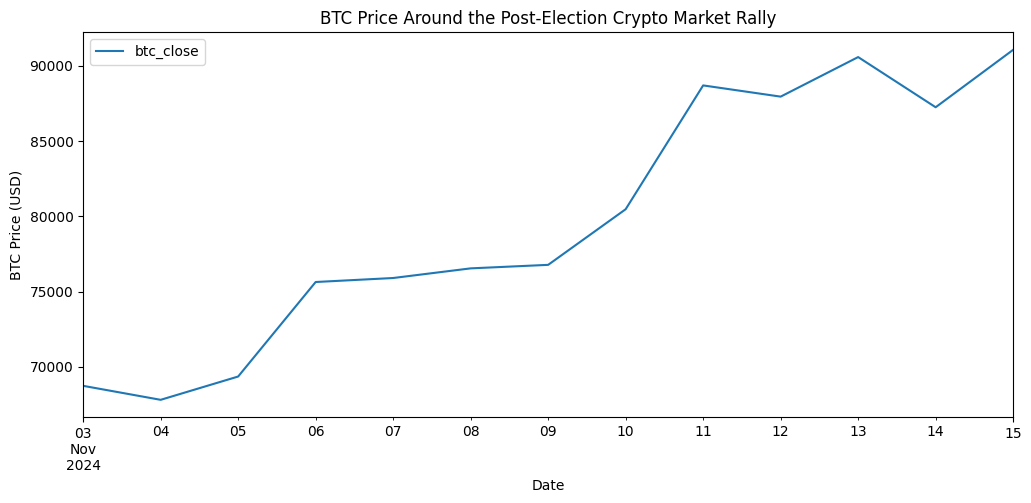

In [5]:
ax = election_daily.plot(
    x="date",
    y="btc_close",
    figsize=(12, 5),
    title="BTC Price Around the Post-Election Crypto Market Rally"
)

ax.set_xlabel("Date")
ax.set_ylabel("BTC Price (USD)")

Text(0, 0.5, 'Daily Return (%)')

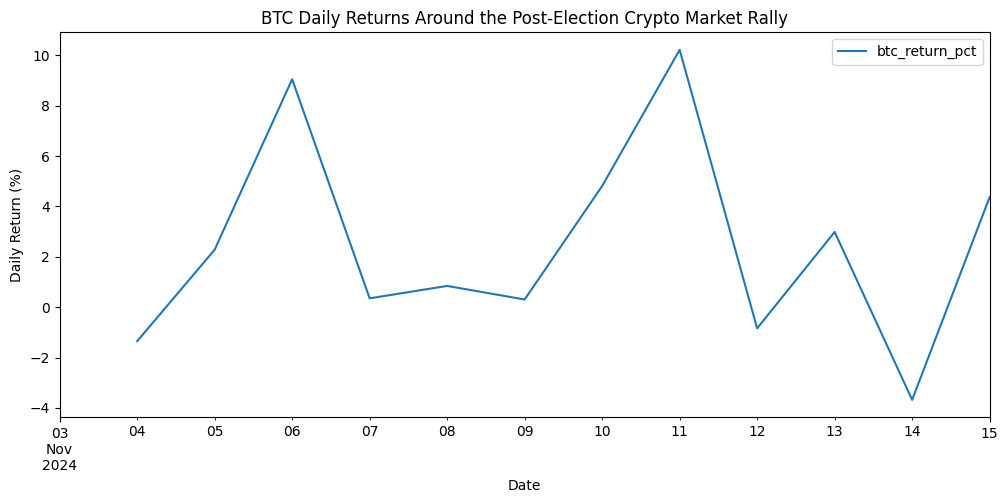

In [6]:
ax = election_daily.plot(
    x="date",
    y="btc_return_pct",
    figsize=(12, 5),
    title="BTC Daily Returns Around the Post-Election Crypto Market Rally"
)

ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")

Text(0, 0.5, 'ETH Price (USD)')

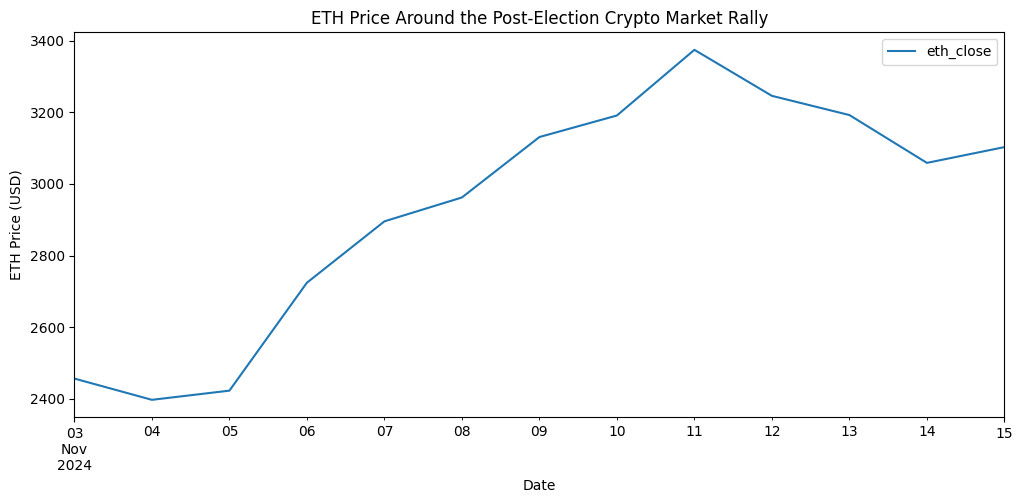

In [7]:
ax = election_daily.plot(
    x="date",
    y="eth_close",
    figsize=(12, 5),
    title="ETH Price Around the Post-Election Crypto Market Rally"
)

ax.set_xlabel("Date")
ax.set_ylabel("ETH Price (USD)")

Text(0, 0.5, 'Daily Return (%)')

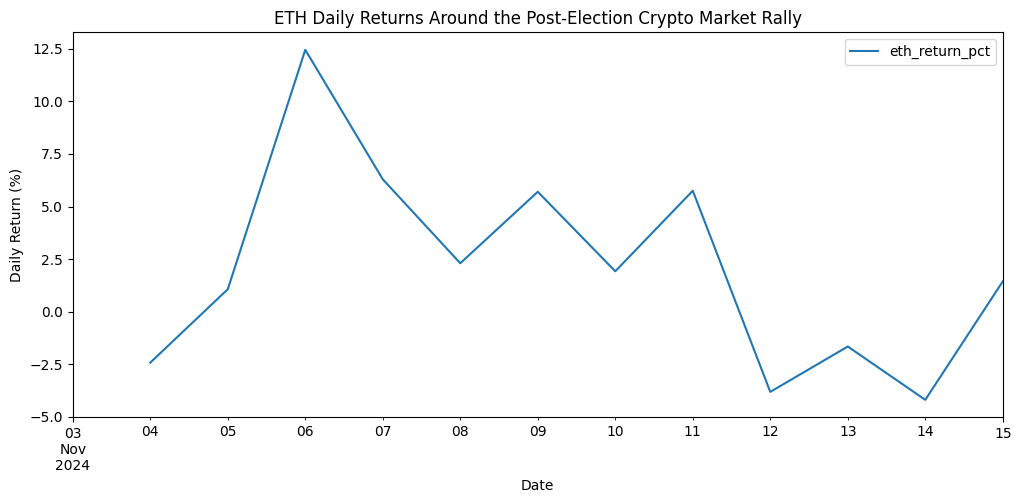

In [8]:
ax = election_daily.plot(
    x="date",
    y="eth_return_pct",
    figsize=(12, 5),
    title="ETH Daily Returns Around the Post-Election Crypto Market Rally"
)

ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")

### Daily Observation

The daily data shows a clear positive shift in the broader crypto market during the post-election period.

BTC and ETH both moved substantially higher during the following days, although the rally did not occur as one immediate price jump at the election timestamp.

Instead, strong positive movements continued to develop across the post-election window.

This makes the selected period useful for the project because it provides a market environment that is very different from the LUNA, Celsius and SVB cases:

> **the volatile assets are rising strongly rather than falling.**

The election is used as a reference point for this period, not as proof that it caused every observed BTC or ETH movement.

## 2. Hourly Market Stress

The daily analysis shows the broader post-election rally.

Hourly BTC and ETH data provides a more detailed view of how the positive market movement developed within the selected period.

The purpose is to measure the timing and magnitude of short-term market movements rather than to attribute each hourly change directly to the election result.

In [9]:
btc_election_hourly = pd.read_csv('../data/processed/hourly/binance/btc_election_hourly_processed.csv', parse_dates=["open_time"])
btc_election_hourly.head()

,open_time,open,high,low,close,volume
0,2024-10-23 00:00:00,67426.01,67472.83,67130.43,67179.13,577.86445
1,2024-10-23 01:00:00,67179.13,67386.94,67179.13,67348.46,393.55985
2,2024-10-23 02:00:00,67348.46,67386.93,67068.28,67096.00,581.36673
3,2024-10-23 03:00:00,67095.99,67180.92,66890.00,67082.10,639.25878
4,2024-10-23 04:00:00,67082.10,67249.84,66999.99,67217.48,515.38779


In [10]:
election_btc_detail = btc_election_hourly[
    (btc_election_hourly["open_time"] >= "2024-11-03") &
    (btc_election_hourly["open_time"] < "2024-11-15")
].copy()

In [11]:
election_btc_detail["btc_hourly_return_pct"] = (election_btc_detail["close"].pct_change() * 100)
election_btc_detail[["open_time", "close", "btc_hourly_return_pct"]].sort_values(by='btc_hourly_return_pct').head()

,open_time,close,btc_hourly_return_pct
523,2024-11-13 19:00:00,90193.51,-2.833847
542,2024-11-14 14:00:00,88720.03,-2.241643
548,2024-11-14 20:00:00,87612.66,-2.069358
489,2024-11-12 09:00:00,87630.89,-1.847132
331,2024-11-05 19:00:00,68995.99,-1.757084


In [12]:
election_btc_detail[["open_time", "close", "btc_hourly_return_pct"]].sort_values(by='btc_hourly_return_pct', ascending=False).head()

,open_time,close,btc_hourly_return_pct
338,2024-11-06 02:00:00,73077.05,2.739031
518,2024-11-13 14:00:00,91508.00,2.642666
336,2024-11-06 00:00:00,71096.04,2.485195
436,2024-11-10 04:00:00,79122.02,2.481751
498,2024-11-12 18:00:00,88796.41,2.104660


Text(0, 0.5, 'BTC Price (USDT)')

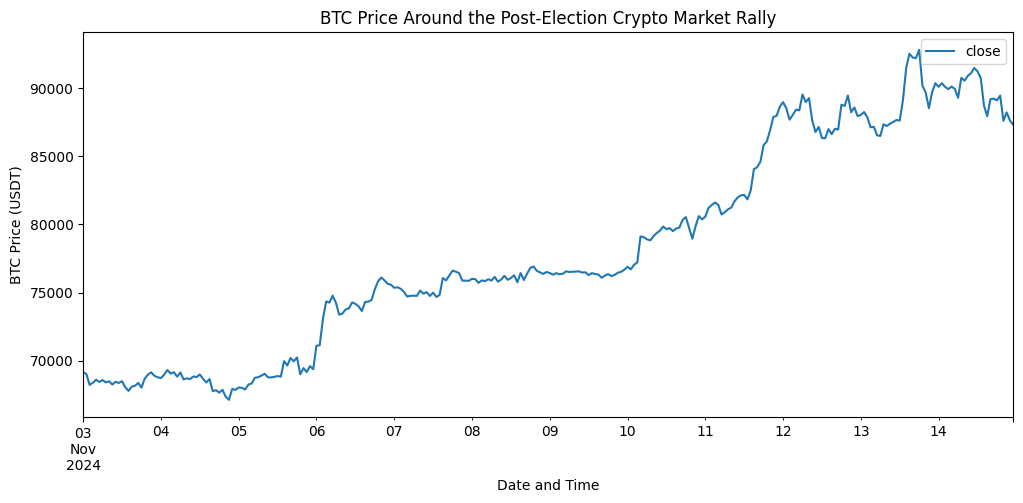

In [13]:
ax = election_btc_detail.plot(
    x="open_time",
    y="close",
    figsize=(12, 5),
    title="BTC Price Around the Post-Election Crypto Market Rally"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("BTC Price (USDT)")

Text(0, 0.5, 'BTC Hourly Returns (%)')

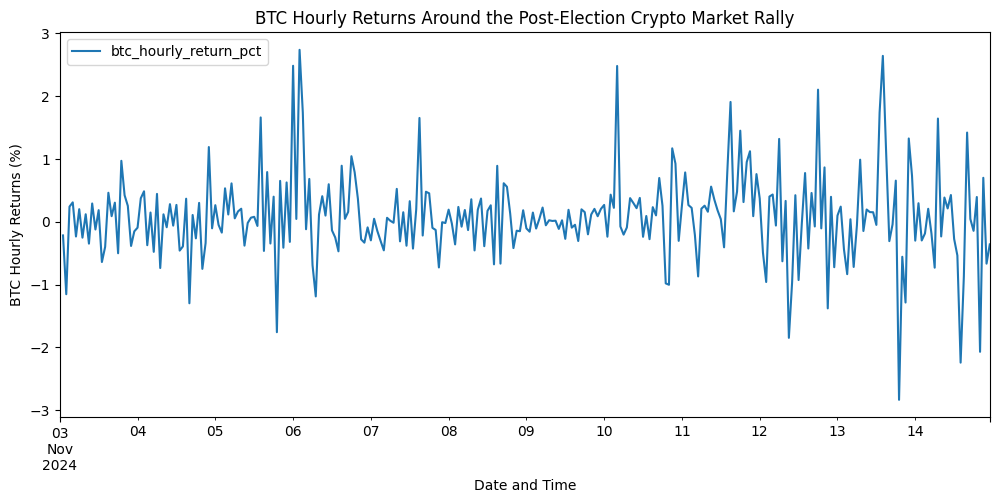

In [14]:
ax = election_btc_detail.plot(
    x="open_time",
    y="btc_hourly_return_pct",
    figsize=(12, 5),
    title="BTC Hourly Returns Around the Post-Election Crypto Market Rally"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("BTC Hourly Returns (%)")

In [15]:
eth_election_hourly = pd.read_csv('../data/processed/hourly/binance/eth_election_hourly_processed.csv', parse_dates=["open_time"])
eth_election_hourly.head()

,open_time,open,high,low,close,volume
0,2024-10-23 00:00:00,2622.81,2628.20,2611.92,2614.09,7051.0419
1,2024-10-23 01:00:00,2614.09,2625.43,2613.81,2624.16,4605.2281
2,2024-10-23 02:00:00,2624.14,2624.50,2610.37,2613.19,5899.9324
3,2024-10-23 03:00:00,2613.18,2617.75,2601.18,2616.50,10813.8312
4,2024-10-23 04:00:00,2616.49,2619.91,2610.07,2617.25,6008.5439


In [16]:
election_eth_detail = eth_election_hourly[
    (eth_election_hourly["open_time"] >= "2024-11-03") &
    (eth_election_hourly["open_time"] < "2024-11-15")
].copy()

In [17]:
election_eth_detail["eth_hourly_return_pct"] = (election_eth_detail["close"].pct_change() * 100)
election_eth_detail[["open_time", "close", "eth_hourly_return_pct"]].sort_values(by='eth_hourly_return_pct').head()

,open_time,close,eth_hourly_return_pct
523,2024-11-13 19:00:00,3158.81,-3.407100
490,2024-11-12 10:00:00,3281.13,-2.304580
309,2024-11-04 21:00:00,2371.21,-2.125315
489,2024-11-12 09:00:00,3358.53,-1.815742
542,2024-11-14 14:00:00,3109.40,-1.806044


In [18]:
election_eth_detail[["open_time", "close", "eth_hourly_return_pct"]].sort_values(by='eth_hourly_return_pct', ascending=False).head()

,open_time,close,eth_hourly_return_pct
338,2024-11-06 02:00:00,2568.30,3.460361
518,2024-11-13 14:00:00,3320.20,3.263168
361,2024-11-07 01:00:00,2813.46,3.219723
544,2024-11-14 16:00:00,3171.20,3.038652
336,2024-11-06 00:00:00,2484.90,2.573734


Text(0, 0.5, 'ETH Price (USDT)')

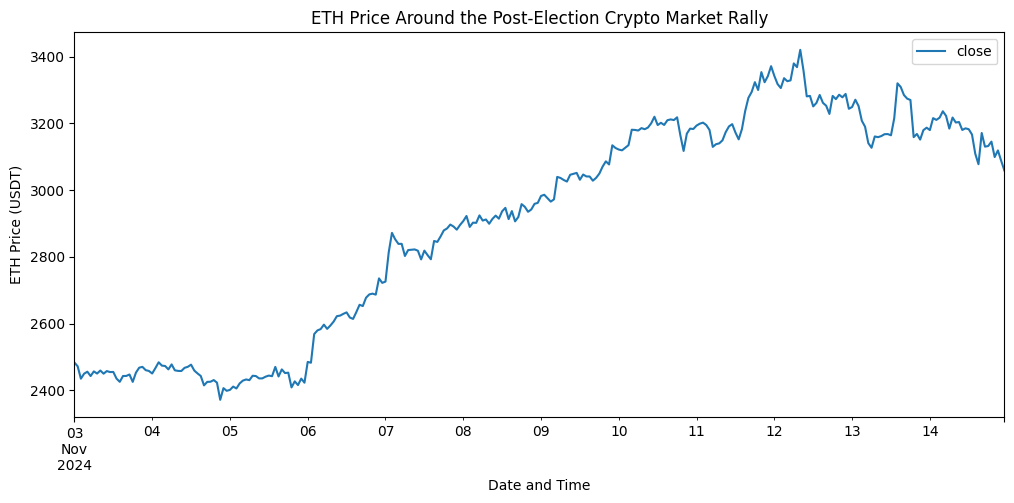

In [19]:
ax = election_eth_detail.plot(
    x="open_time",
    y="close",
    figsize=(12, 5),
    title="ETH Price Around the Post-Election Crypto Market Rally"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("ETH Price (USDT)")

Text(0, 0.5, 'ETH Hourly Returns (%)')

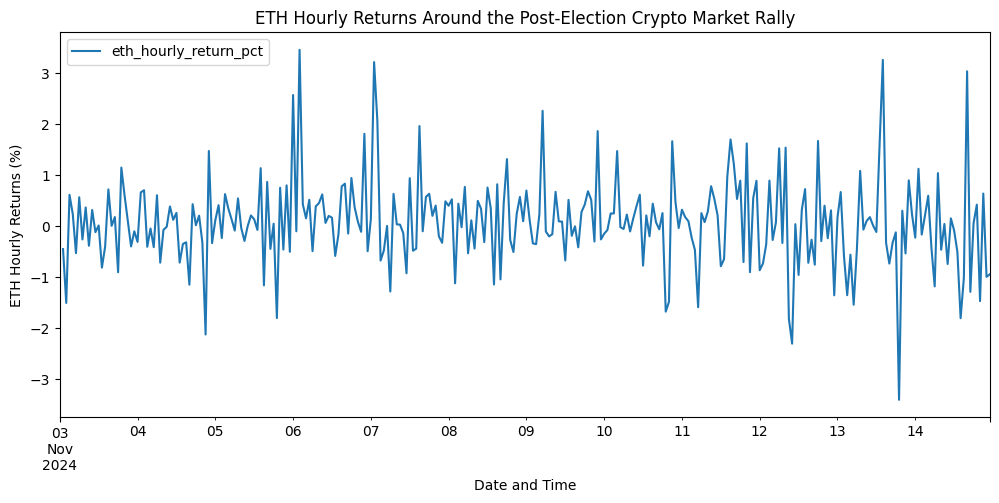

In [20]:
ax = election_eth_detail.plot(
    x="open_time",
    y="eth_hourly_return_pct",
    figsize=(12, 5),
    title="ETH Hourly Returns Around the Post-Election Crypto Market Rally"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("ETH Hourly Returns (%)")

### Hourly Observation

The hourly data confirms that the post-election period contained substantial short-term movements in both BTC and ETH.

However, the strongest hourly movements do not occur exactly at the election T0. Market activity continues to develop over the following days.

This supports treating the election as a **reference point for the beginning of the post-election period**, rather than as proof of an immediate one-time price reaction.

For this project, the important observation is that stablecoins were operating during a period of strong positive movement and elevated activity in the broader crypto market.

## 3. Event Timeline and T0 Definition

For this case, **T0 is the moment when the U.S. presidential election result became publicly confirmed by a major independent news organization**.

The Associated Press declared Donald Trump the winner of Wisconsin and, at the same time, the winner of the 2024 U.S. presidential election at **05:34 ET on 6 November 2024**.

This corresponds to:

**6 November 2024, 10:34 UTC**

The Wisconsin result pushed Trump above the 270 electoral-vote threshold required to win the presidency.

This timestamp is used as the reference point for the post-election analysis.

The purpose is not to assume that the election result caused every subsequent BTC or ETH price movement. Instead, T0 marks a clear publicly observable event after which the market began operating with confirmed information about the election outcome.

**Source:** Associated Press — *Calling the 2024 presidential race state by state*

The strong crypto-market movements observed during the following days are therefore treated as the **post-election response window**, rather than as separate Trump-related events.

In [34]:
election_t0 = pd.Timestamp(
    "2024-11-06 10:34:00",
    tz="UTC"
)

## 4. Stablecoin Stability During the Market Rally

BTC and ETH experienced substantial positive price movements during the post-election period.

The next step is to examine whether this broader market rally was accompanied by meaningful instability in USDT or USDC.

Both stablecoins are designed to remain close to **$1**, so the analysis focuses on:

1. how far each stablecoin moved from $1;
2. whether any deviations were persistent;
3. whether one stablecoin behaved differently from the other.

Unlike the SVB case, there is no known event-specific reserve exposure affecting only one of the two stablecoins. The comparison therefore helps determine whether strong positive crypto-market conditions alone were associated with meaningful stablecoin instability.

In [35]:
usdt_election_hourly = pd.read_csv('../data/processed/hourly/coinbase/usdt_election_hourly_processed.csv', parse_dates=["timestamp"])
usdt_election_hourly.head()

,timestamp,low,high,open,close,volume
0,2024-10-23 00:00:00+00:00,0.92521,0.92573,0.92544,0.92540,68237.89
1,2024-10-23 01:00:00+00:00,0.92533,0.92559,0.92546,0.92554,22312.45
2,2024-10-23 02:00:00+00:00,0.92471,0.92553,0.92553,0.92471,45357.44
3,2024-10-23 03:00:00+00:00,0.92472,0.92524,0.92472,0.92493,29704.81
4,2024-10-23 04:00:00+00:00,0.92495,0.92517,0.92496,0.92507,13540.32


In [36]:
usdc_election_hourly = pd.read_csv('../data/processed/hourly/coinbase/usdc_election_hourly_processed.csv', parse_dates=["timestamp"])
usdc_election_hourly.head()

,timestamp,low,high,open,close,volume
0,2024-10-23 00:00:00+00:00,0.9258,0.9262,0.9258,0.9259,299305.82
1,2024-10-23 01:00:00+00:00,0.9258,0.9262,0.9259,0.9261,86413.49
2,2024-10-23 02:00:00+00:00,0.9254,0.9261,0.9260,0.9255,56516.49
3,2024-10-23 03:00:00+00:00,0.9253,0.9257,0.9255,0.9255,149512.68
4,2024-10-23 04:00:00+00:00,0.9254,0.9257,0.9255,0.9256,84294.57


In [37]:
eur_election_hourly = pd.read_csv('../data/processed/fx/eur_usd_election_hourly_processed.csv', parse_dates=["timestamp"])
eur_election_hourly.head()

,timestamp,open,high,low,close,volume
0,2024-10-23 00:00:00+00:00,1.07962,1.08008,1.07922,1.07952,10020690000
1,2024-10-23 01:00:00+00:00,1.07953,1.07983,1.07936,1.07949,10165870000
2,2024-10-23 02:00:00+00:00,1.07948,1.08053,1.07947,1.08045,10047610000
3,2024-10-23 03:00:00+00:00,1.08046,1.08053,1.07987,1.08021,7939800000
4,2024-10-23 04:00:00+00:00,1.08022,1.08026,1.07995,1.08020,6901280000


In [38]:
for name, df in {
    "USDT/EUR": usdt_election_hourly,
    "USDC/EUR": usdc_election_hourly,
    "EUR/USD": eur_election_hourly
}.items():
    print(
        name,
        "| rows:", len(df),
        "| start:", df["timestamp"].min(),
        "| end:", df["timestamp"].max()
    )

USDT/EUR | rows: 721 | start: 2024-10-23 00:00:00+00:00 | end: 2024-11-22 00:00:00+00:00
USDC/EUR | rows: 721 | start: 2024-10-23 00:00:00+00:00 | end: 2024-11-22 00:00:00+00:00
EUR/USD | rows: 549 | start: 2024-10-23 00:00:00+00:00 | end: 2024-11-22 21:00:00+00:00


### Data Coverage and FX Alignment

Crypto markets trade continuously, while the EUR/USD FX benchmark does not provide the same weekend coverage.

As in the previous event studies, missing weekend FX observations are filled using the most recent available EUR/USD rate. A separate flag is retained to distinguish observed FX rates from carried-forward values.

In [39]:
election_stablecoin_fx = (
    usdt_election_hourly[["timestamp", "close"]]
    .rename(columns={"close": "usdt_eur_close"})
    .merge(
        usdc_election_hourly[["timestamp", "close"]]
        .rename(columns={"close": "usdc_eur_close"}),
        on="timestamp",
        how="outer"
    )
    .merge(
        eur_election_hourly[["timestamp", "close"]]
        .rename(columns={"close": "eur_usd_close"}),
        on="timestamp",
        how="left"
    )
    .sort_values("timestamp")
)

election_stablecoin_fx = election_stablecoin_fx[
    (election_stablecoin_fx["timestamp"] >= trump_t0 - pd.Timedelta(days=5))
    & (election_stablecoin_fx["timestamp"] <= trump_t0 + pd.Timedelta(days=9))
].copy()

### FX Preparation Window

A wider time window is retained at this stage to support the EUR/USD benchmark alignment.

Because the FX market does not provide continuous weekend coverage, additional observations before the final analytical window are required so that the most recent available EUR/USD rate can be carried forward where necessary.

This wider range is used only for data preparation.

The event-specific stablecoin metrics are calculated separately within the narrower analytical window defined below.

In [40]:
election_stablecoin_fx["fx_rate_observed"] = (
    election_stablecoin_fx["eur_usd_close"].notna()
)

election_stablecoin_fx["eur_usd_benchmark"] = (
    election_stablecoin_fx["eur_usd_close"].ffill()
)

print(
    "Missing FX benchmark values:",
    election_stablecoin_fx["eur_usd_benchmark"].isna().sum()
)

Missing FX benchmark values: 0


### Converting Stablecoin Prices to USD

Coinbase quotes USDT and USDC against EUR, while both stablecoins are designed to remain close to **$1**.

To evaluate their stability directly, the EUR prices are converted into approximate USD values:

`stablecoin/EUR × EUR/USD = implied stablecoin/USD`

A value close to **$1.00** indicates that the stablecoin is maintaining its intended peg.

The same calculation is applied to both USDT and USDC so their behavior can be compared consistently.

In [28]:
election_stablecoin_fx["usdt_usd_implied"] = (
    election_stablecoin_fx["usdt_eur_close"]
    * election_stablecoin_fx["eur_usd_benchmark"]
)

election_stablecoin_fx["usdc_usd_implied"] = (
    election_stablecoin_fx["usdc_eur_close"]
    * election_stablecoin_fx["eur_usd_benchmark"]
)

In [29]:
election_stablecoin_fx[
    ["usdt_usd_implied", "usdc_usd_implied"]
].describe()

,usdt_usd_implied,usdc_usd_implied
count,336.000000,336.000000
mean,0.999157,0.998762
std,0.002706,0.003053
min,0.970467,0.968343
25%,0.998739,0.997906
50%,0.999875,0.999794
75%,1.000555,1.000330
max,1.002745,1.003191


The summary statistics show very similar behavior for USDT and USDC. Both remain close to $1 on average and display relatively small overall variation.

Unlike the SVB case, the initial summary does not indicate a clear asset-specific stablecoin shock.

In [30]:
usdt_min_idx = (
    election_stablecoin_fx["usdt_usd_implied"].idxmin()
)

usdc_min_idx = (
    election_stablecoin_fx["usdc_usd_implied"].idxmin()
)

usdt_max_idx = (
    election_stablecoin_fx["usdt_usd_implied"].idxmax()
)

usdc_max_idx = (
    election_stablecoin_fx["usdc_usd_implied"].idxmax()
)

election_stablecoin_fx.loc[
    [usdt_min_idx, usdc_min_idx, usdt_max_idx, usdc_max_idx],
    [
        "timestamp",
        "usdt_usd_implied",
        "usdc_usd_implied",
        "eur_usd_close",
        "eur_usd_benchmark",
        "fx_rate_observed"
    ]
]

,timestamp,usdt_usd_implied,usdc_usd_implied,eur_usd_close,eur_usd_benchmark,fx_rate_observed
490,2024-11-12 10:00:00+00:00,0.970467,0.968343,1.06178,1.06178,True
490,2024-11-12 10:00:00+00:00,0.970467,0.968343,1.06178,1.06178,True
286,2024-11-03 22:00:00+00:00,1.002745,1.003191,1.08806,1.08806,True
286,2024-11-03 22:00:00+00:00,1.002745,1.003191,1.08806,1.08806,True


### Stablecoin Price Extremes

The lowest implied values of USDT and USDC occur at approximately the same time and are similar in magnitude.

This is important because there is no clear divergence between the two stablecoins comparable to the USDC-specific stress observed during the SVB event.

A simultaneous movement in both assets provides weaker evidence of an asset-specific stablecoin problem and suggests that the deviation should be interpreted cautiously in the context of the broader market and the FX conversion methodology.

In [31]:
election_stablecoin_fx["usdt_peg_deviation_pct"] = (
    election_stablecoin_fx["usdt_usd_implied"] - 1
) * 100

election_stablecoin_fx["usdc_peg_deviation_pct"] = (
    election_stablecoin_fx["usdc_usd_implied"] - 1
) * 100
election_stablecoin_fx.head()

,timestamp,usdt_eur_close,usdc_eur_close,eur_usd_close,fx_rate_observed,eur_usd_benchmark,usdt_usd_implied,usdc_usd_implied,usdt_peg_deviation_pct,usdc_peg_deviation_pct
227,2024-11-01 11:00:00+00:00,0.91993,0.9207,1.08679,True,1.08679,0.999771,1.000608,-0.022928,0.060755
228,2024-11-01 12:00:00+00:00,0.91820,0.9188,1.08861,True,1.08861,0.999562,1.000215,-0.043830,0.021487
229,2024-11-01 13:00:00+00:00,0.91964,0.9201,1.08693,True,1.08693,0.999584,1.000084,-0.041569,0.008429
230,2024-11-01 14:00:00+00:00,0.92092,0.9211,1.08544,True,1.08544,0.999603,0.999799,-0.039660,-0.020122
231,2024-11-01 15:00:00+00:00,0.92196,0.9221,1.08484,True,1.08484,1.000179,1.000331,0.017909,0.033096


In [32]:
election_stress_window = election_stablecoin_fx[
    election_stablecoin_fx["timestamp"].between(
        "2024-11-03 00:00:00+00:00",
        "2024-11-14 23:00:00+00:00"
    )
].copy()

In [33]:
thresholds = [0.995, 0.990, 0.980]

for asset in ["usdt", "usdc"]:
    print(f"\n{asset.upper()}")

    for threshold in thresholds:
        hours_below = (
            election_stress_window[f"{asset}_usd_implied"] < threshold
        ).sum()

        print(
            f"Hourly observations below ${threshold:.3f}:",
            hours_below
        )


USDT
Hourly observations below $0.995: 21
Hourly observations below $0.990: 2
Hourly observations below $0.980: 1

USDC
Hourly observations below $0.995: 32
Hourly observations below $0.990: 3
Hourly observations below $0.980: 1


### Peg Stability Finding

Both USDT and USDC experienced temporary deviations from $1 during the selected period, but their behaviour was broadly similar.

USDT recorded:

- **21 hourly observations below $0.995**
- **2 below $0.990**
- **1 below $0.980**

USDC recorded:

- **32 hourly observations below $0.995**
- **3 below $0.990**
- **1 below $0.980**

The two stablecoins also reached their lowest implied values at the same timestamp, **12 November at 10:00 UTC**, at approximately **$0.9705 for USDT** and **$0.9683 for USDC**.

This simultaneous and similar movement does not resemble the asset-specific stress observed in the SVB case.

Most importantly, the strong appreciation of BTC and ETH during the post-election period was not accompanied by a comparable sustained change in stablecoin value.

The analysis therefore does not identify a clear stablecoin-specific valuation shock associated with the positive market rally.

## 5. Business Interpretation

Within the modelled payment scenario, the absence of a strong USDT reaction is itself informative.

If incoming funds had remained in BTC or ETH during this period, their market value could have increased substantially as crypto prices rose.

Under the modelled strategy, those funds had already been converted into USDT, so the operational balance remained comparatively stable instead of participating in the market rally.

For a company using stablecoins to hold operational funds, the absence of a strong stablecoin reaction is itself informative.

If operational funds had remained in BTC or ETH during this period, their market value could have increased substantially as crypto prices rose.

If those funds had already been converted into USDT, their value would instead have remained approximately stable.

This represents a trade-off rather than a stablecoin failure:

- holding BTC or ETH preserves exposure to potential market gains, but also to potential losses;
- converting operational funds into stablecoins reduces exposure to both directions of market movement.

For payment and treasury operations, this can be desirable. Operational balances are normally held to support payments, settlements and liquidity needs rather than to speculate on future crypto prices.

The potential upside given up after conversion can therefore be understood as an **opportunity cost of reducing market exposure**, rather than as a direct financial loss.

## 6. Post-Election Rally Case Conclusion

The post-election period provides a useful contrast to the crisis scenarios examined elsewhere in the project.

BTC and ETH experienced strong positive market movements after the U.S. election, but USDT and USDC remained broadly anchored around their intended $1 value.

The analysis does not identify a clear stablecoin-specific reaction to the election or the subsequent crypto-market rally. Temporary deviations occurred, but they were similar across both stablecoins and did not resemble the concentrated instability observed in event-specific cases such as SVB.

This is an important result.

In the modelled strategy, USDT is not intended to capture the upside of a crypto-market rally. Its role is to reduce exposure to changes in the price of volatile assets.

During this event, that mechanism broadly worked as intended: BTC and ETH moved substantially, while the modelled USDT balance remained comparatively stable.

The trade-off is **opportunity cost**. A company that converted BTC or ETH into stablecoins before the rally would not participate in the subsequent price gains. However, the same decision would also reduce exposure to equivalent losses during a market decline.

For operational treasury management, the objective is therefore not to maximize market returns, but to maintain a more predictable value for funds needed for payments and settlements.